<a href="https://colab.research.google.com/github/SandraVargasAI/Mineria-de-Datos-/blob/main/MD_C5_Ejercicios_del_Libro_(SV).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**ALUMNA: SANDRA VARGAS**
# **Ejercicio para la Sección 1**

**Objetivo**: Aplicar técnicas de manejo de valores faltantes en un dataset real.

**Instrucciones**:

1. Carga el dataset Titanic de Seaborn (sns.load_dataset("titanic")).
2. Identifica qué columnas tienen valores nulos y cuántos valores faltantes hay en cada una.
3. Elimina las filas con valores nulos en la columna age.
4. Imputa los valores faltantes en la columna embark_town usando la moda.
5. Explica por qué elegiste esas estrategias y qué impacto pueden tener en un análisis posterior.

# 1. Carga el dataset Titanic de Seaborn (sns.load_dataset("titanic")).

In [1]:
import seaborn as sns
import pandas as pd

# Cargar dataset Titanic
df = sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


# 2. Identifica qué columnas tienen valores nulos y cuántos valores faltantes hay en cada una.

In [2]:
# Ver cantidad de valores nulos por columna
# print("Valores nulos por columna:", "\n", df.isnull().sum())

def diagnostico_nulos(df, nombre='Dataset'):
    '''Muestra un resumen de valores nulos por columna.'''
    nulos = df.isnull().sum()
    pct   = (df.isnull().mean() * 100).round(1)
    resumen = pd.DataFrame({'Nulos': nulos, 'Porcentaje (%)': pct})
    resumen = resumen[resumen['Nulos'] > 0].sort_values('Nulos', ascending=False)
    print(f'--- {nombre} — columnas con valores faltantes ---')
    if len(resumen) == 0:
        print('  Sin valores faltantes.')
    else:
        print(resumen.to_string())
    print(f'  Total filas: {len(df)}')
    print()

diagnostico_nulos(df, 'Titanic')

#print(f'Titanic cantidad de Filas:  {df.shape[0]}')


--- Titanic — columnas con valores faltantes ---
             Nulos  Porcentaje (%)
deck           688            77.2
age            177            19.9
embarked         2             0.2
embark_town      2             0.2
  Total filas: 891



# 3. Elimina las filas con valores nulos en la columna age.


In [3]:
# 1. Eliminar filas con valores nulos en 'age' y crear una copia explícita
df_cleaned = df.dropna(subset=["age"]).copy()

print(f'Titanic cantidad de Filas antes de Eliminar Nulos:  {df.shape[0]}')

print("\nResultado después de Eliminar Nulos. \n")
diagnostico_nulos(df_cleaned, 'Titanic')

#print("\nValores nulos después del preprocesamiento:", "\n", df_cleaned.isnull().sum())

Titanic cantidad de Filas antes de Eliminar Nulos:  891

Resultado después de Eliminar Nulos. 

--- Titanic — columnas con valores faltantes ---
             Nulos  Porcentaje (%)
deck           530            74.2
embarked         2             0.3
embark_town      2             0.3
  Total filas: 714



# 4. Imputa los valores faltantes en la columna embark_town usando la moda.


In [4]:
# 2. Imputar valores nulos en 'embark_town' con la moda, reasignando la columna

print("Filas con valores nulos en la columna 'embark_town', ANTES de imputar:")
display(df_cleaned[df_cleaned['embark_town'].isnull()])

print(f"\n---- La moda de la columna 'embark_town' es: {df_cleaned['embark_town'].mode()[0]}")

df_cleaned["embark_town"] = df_cleaned["embark_town"].fillna(df_cleaned["embark_town"].mode()[0])

print("\nResultado después de Imputar la Moda. \n")
diagnostico_nulos(df_cleaned, 'Titanic')



Filas con valores nulos en la columna 'embark_town', ANTES de imputar:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
61,1,1,female,38.0,0,0,80.0,NaN,First,woman,False,B,NaN,yes,True
829,1,1,female,62.0,0,0,80.0,NaN,First,woman,False,B,NaN,yes,True



---- La moda de la columna 'embark_town' es: Southampton

Resultado después de Imputar la Moda. 

--- Titanic — columnas con valores faltantes ---
          Nulos  Porcentaje (%)
deck        530            74.2
embarked      2             0.3
  Total filas: 714



### Visualización de las filas 61 y 829, después de imputar la moda.

In [5]:
print("Filas 61 y 829 del DataFrame df_cleaned, después de imputar la moda:")
display(df_cleaned.loc[[61, 829]])

Filas 61 y 829 del DataFrame df_cleaned, después de imputar la moda:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
61,1,1,female,38.0,0,0,80.0,NaN,First,woman,False,B,Southampton,yes,True
829,1,1,female,62.0,0,0,80.0,NaN,First,woman,False,B,Southampton,yes,True


# 5. Explica por qué elegiste esas estrategias y qué impacto pueden tener en un análisis posterior.

Considerando que las variables analizadas corresponden a la categoría MCAR, lo que indica que la faltante del dato se debe a razones aleatorias, si bien se eliminan filas según la variable 'age',  las estrategias utilizadas	no afectan el analisis posteior ya que el dataset sigue siendo representativo.

# **Preguntas de Reflexión**

*1. ¿Cómo afecta la eliminación de datos a la cantidad de información disponible?*

La eliminación de datos reduce directamente la cantidad de información disponible, y su impacto depende de qué y cuánto se elimine:


* quitar registros o variables, disminuye el dataset para analizar, lo que puede limitar los resultados.
* si se eliminan datos importantes, se pueden perder patrones o relaciones clave.
* eliminar datos erróneos, duplicados o irrelevantes puede hacer el análisis más preciso, a veces mejora la calidad del análisis.
* si la eliminación no es equilibrada (por ejemplo, se eliminan más datos de un grupo que de otro), los resultados pueden volverse sesgados.
* en modelos de machine learning, menos datos suele significar menor rendimiento. Menor capacidad predictiva.
* con menos datos, el análisis puede ser más rápido y fácil de interpretar.

*2. ¿Qué problemas pueden surgir si imputamos valores en variables categóricas?*

Algunos de los posibles problemas a considerar son:
* si la categoría imputada no refleja la verdadera distribución de la variable, puede provocar una distorción de la distribución original.
* la imputación de forma simple con la moda, puede reducir la varianza de la variable.
* si los valores faltantes no son aleatorios, imputar la moda puede introducir sesgo ya que distorciona la representación de esa variable.
* la imputación puede crear relaciones ficticias entre la variable imputada y otras variables.
* puede haber pérdida de información sobre la falta de datos, la falta de ese dato puede representar información real del dataset que puede ser analizada.

*3. ¿Cómo podríamos validar que nuestras imputaciones no introducen sesgos?*

Podemos validar que las imputaciones no introducen sesgo, de la siguientes formas:
* comparar distribuciones, para ver que no cambian significativamente despues de la imputación.
* análisis de sensibilidad.
* modelado comparativo, entrenar el modelocon o sin imputación, para comparar su rendimiento.
* indicadoresde nulos, utilizar una nueva variable binaria que indique si el valor fue imputado.
* validación cruzada cuidadosa, imputar dentro de cada fold para evitar fuga de información y sesgos.

# Ejercicio para la Sección 2

**Objetivo**: Aplicar detección y tratamiento de outliers en un dataset real.

**Instrucciones**:

1. Carga el dataset Diamonds de Seaborn (sns.load_dataset("diamonds")).
2. Crea un boxplot para visualizar outliers en la columna price.
3. Aplica el método IQR para detectar y eliminar valores atípicos en price.
4. Explica qué impacto tendría eliminar estos valores en un modelo de Machine Learning.

# 1. Carga el dataset Diamonds de Seaborn (sns.load_dataset("diamonds")).


In [6]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import zscore

# Cargar dataset
df = sns.load_dataset("diamonds")
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


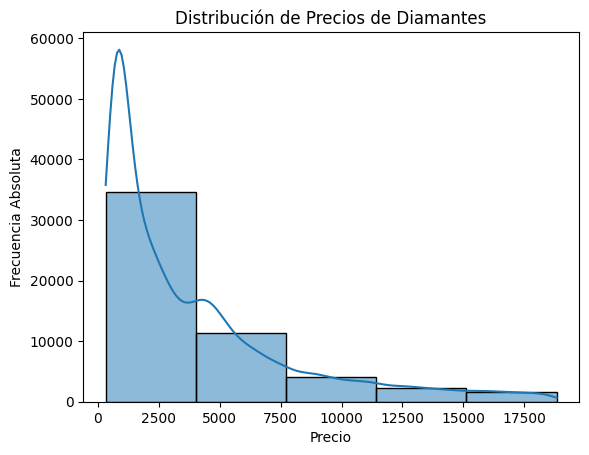

In [7]:
# Histograma de price
sns.histplot(df["price"], bins=5, kde=True)
plt.title("Distribución de Precios de Diamantes")
plt.xlabel("Precio")
plt.ylabel("Frecuencia Absoluta")
plt.show()

# 2. Crea un boxplot para visualizar outliers en la columna price.


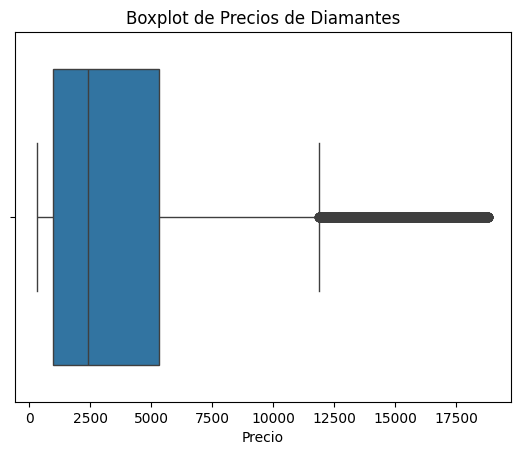

In [8]:
# Boxplot de precios
sns.boxplot(x=df["price"])
plt.title("Boxplot de Precios de Diamantes")
plt.xlabel("Precio")
plt.show()

#print(df["price"].describe().round(2))

### Medidas Características del Boxplot de `price`

In [9]:
# Calcular las medidas características del boxplot para la columna 'price'
min_price = df['price'].min()
Q1_price = df['price'].quantile(0.25)
median_price = df['price'].median()
Q3_price = df['price'].quantile(0.75)
max_price = df['price'].max()

print(f"Valor Mínimo (sin considerar outliers): {min_price}")
print(f"Primer Cuartil (Q1 - 25%): {Q1_price}")
print(f"Mediana (Q2 - 50%): {median_price}")
print(f"Tercer Cuartil (Q3 - 75%): {Q3_price}")
print(f"Valor Máximo (sin considerar outliers): {max_price}")

Valor Mínimo (sin considerar outliers): 326
Primer Cuartil (Q1 - 25%): 950.0
Mediana (Q2 - 50%): 2401.0
Tercer Cuartil (Q3 - 75%): 5324.25
Valor Máximo (sin considerar outliers): 18823


# 3. Aplica el método IQR para detectar y eliminar valores atípicos en price.


In [10]:
# Cálculo del Rango Intercuartílico (IQR)
# Se aplica ya que se trata de datos con distribución sesgada
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)
IQR = Q3 - Q1

print("Primer Cuartil (Q1):", Q1)
print("Tercer Cuartil (Q3):", Q3)
print("Rango Intercuartílico (IQR):", IQR)

# Definir límites para detectar outliers
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print("\nLímite Inferior:", limite_inferior)
print("Límite Superior:", limite_superior)

# Filtrar valores dentro de los límites
df_cleaned = df[(df["price"] >= limite_inferior) & (df["price"] <= limite_superior)]
print('\n---- Resultado de filtrar valores dentro de los límites')
print("Antes:", len(df), "Después:", len(df_cleaned))

Primer Cuartil (Q1): 950.0
Tercer Cuartil (Q3): 5324.25
Rango Intercuartílico (IQR): 4374.25

Límite Inferior: -5611.375
Límite Superior: 11885.625

---- Resultado de filtrar valores dentro de los límites
Antes: 53940 Después: 50400


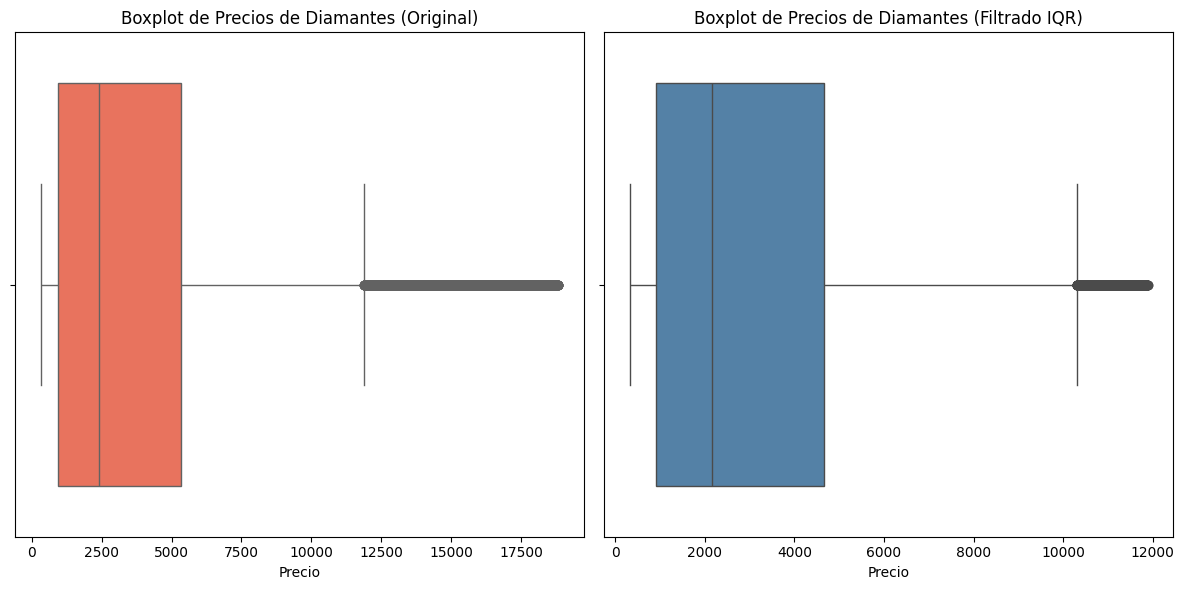

In [11]:
# Boxplot de precios
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

sns.boxplot(x=df["price"], ax=axes[0], color='tomato')
axes[0].set_title("Boxplot de Precios de Diamantes (Original)")
axes[0].set_xlabel("Precio")

sns.boxplot(x=df_cleaned["price"], ax=axes[1], color='steelblue')
axes[1].set_title("Boxplot de Precios de Diamantes (Filtrado IQR)")
axes[1].set_xlabel("Precio")

plt.tight_layout()
plt.show()

# 4. Explica qué impacto tendría eliminar estos valores en un modelo de Machine Learning.

Eliminar estos outliers, mejora la presición del modelo al predecir el precio de los diamantes, sobretodo si dichos outliers eran datos erroneos o valores extrmos que introducían sesgo.

Por otro lado, en el caso de diamantes muy excepcionales, el modelo sería menos efectivo a la hora de predecir su precio.

Hay que tener en cuenta el contexto para dicho modelo.

# **Preguntas de Reflexión**

*1. ¿Cómo cambia la distribución de price después de eliminar outliers?*

Después de eliminar los outliers utilizando el método IQR, la distribución de la columna price cambia de varias maneras:

* el rango total de los precios (la diferencia entre el valor máximo y mínimo) se reduce significativamente. Los valores extremadamente altos (y potencialmente bajos, aunque en este caso los outliers eran principalmente hacia arriba) han sido eliminados.
* Menor Varianza y Desviación Estándar: La dispersión de los datos alrededor de la media o mediana se vuelve menor. Esto se debe a que los valores extremos que contribuían a una mayor varianza ya no están presentes.
* Distribución Más Concentrada: Los datos restantes están más agrupados y concentrados alrededor de los valores centrales. El boxplot Filtrado IQR muestra una 'caja' (que representa el 50% central de los datos) y 'bigotes' mucho más cortos y compactos en comparación con el boxplot Original.
* Desaparición o Reducción de Puntos Fuera de los Bigotes: En el boxplot original, veíamos muchos puntos individuales por encima del bigote superior, que representaban los outliers. En el boxplot filtrado, estos puntos desaparecen o se reducen drásticamente, lo que indica que se han eliminado los valores que excedían los límites del IQR.
* Posible Cambio en la Asimetría (Skewness): Si los outliers eran predominantemente en una dirección (como es común en datos de precios, con una cola derecha larga), su eliminación puede hacer que la distribución sea menos asimétrica o incluso más cercana a una distribución normal, dependiendo de la naturaleza de los datos restantes.
* Mejor Representación de la Mayoría de los Datos: La distribución resultante ofrece una visión más clara y representativa del comportamiento de precios de la mayoría de los diamantes, sin la influencia desproporcionada de los valores extremos.

En resumen, la eliminación de outliers 'limpia' la distribución, haciéndola más compacta, menos dispersa y más enfocada en el rango de valores típicos, lo que puede ser beneficioso para ciertos análisis y modelos.


*2. ¿Eliminar outliers mejora siempre un análisis? ¿Cuándo puede ser contraproducente?*

La eliminación de outliers, tiene dos caras, puede mejorar elanálisis  o puede ser contraproducentes. El tratamiento de los outliers dependerá del contexto, la naturaleza de los outliers y el objetivo del análisis.

* puede ser beneficioso para modelos sensibles a valores extremos, mejorando la precisión.
* si los outliers son errores de datos, su eliminación es crucial para la robustez.
* los outliers pueden ser datos válidos y representar información importante.
* eliminar outliers válidos lleva a la pérdida de información y a una comprensión incompleta.
* es contraproducente si el objetivo es analizar o predecir eventos extremos (anomalías, fraudes).
* un método de detección inadecuado puede eliminar datos correctos o pasar por alto los reales.
* algunos modelos de ML son naturalmente robustos a los outliers (ej. árboles de decisión).
* la eliminación indiscriminada puede distorsionar patrones y reducir la capacidad de generalización.

*3. ¿Existen casos en los que los outliers pueden ser la parte más importante de los datos?*

Efectivamente, hay situaciones en los que los outliers son importantes y considerados casos de estudios para el análisis.
Algunos ejemplos son:

* Detección de Anomalías: En ciberseguridad o detección de fraudes, los outliers son las transacciones o actividades sospechosas que se buscan.
* Descubrimiento Científico: En investigación, un outlier puede indicar un nuevo fenómeno, una falla en un experimento o un error significativo.
* Innovación: En ingeniería, los outliers de rendimiento podrían señalar prototipos fallidos o, inversamente, descubrimientos innovadores.
* Análisis de Riesgos: En finanzas, los valores extremos (cisnes negros) son cruciales para entender riesgos de mercado y diseñar estrategias de mitigación.
* Medicina y Salud: Reacciones inusuales a tratamientos o síntomas extremos pueden ser clave para entender enfermedades o desarrollar nuevas terapias.
* Optimización de Procesos: En la manufactura, un outlier de calidad o eficiencia puede revelar un problema crítico o una oportunidad de mejora.
* Comportamiento del Consumidor: Un outlier en el patrón de compra puede indicar un cliente muy valioso o una nueva tendencia de mercado.
* Modelado Predictivo: Ignorar outliers legítimos puede hacer que un modelo falle catastróficamente al encontrarlos en la realidad.
* Validación de Datos: A veces, un outlier es un error de entrada que, al ser identificado, mejora la calidad general del dataset.
* Comprensión Completa: Para una visión holística, es vital entender tanto los patrones comunes como las desviaciones, ya que ambas ofrecen información valiosa.

# **Ejercicio para la Sección 3**

**Objetivo**: Aplicar transformación de datos numéricos y categóricos en un dataset real.

**Instrucciones**:

1. Carga el dataset Titanic de Seaborn (sns.load_dataset("titanic")).
2. Aplica normalización Min-Max en la columna fare.
3. Convierte la columna sex a valores numéricos usando One-Hot Encoding.
4. Explica qué impacto puede tener esta transformación en un modelo de clasificación.

# 1. Carga el dataset Titanic de Seaborn (sns.load_dataset("titanic")).


In [12]:
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Cargar dataset Titanic
df = sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


# 2. Aplica normalización Min-Max en la columna fare.


In [13]:
# Normalización de la columna fare
scaler = MinMaxScaler()
df["fare_normalizado"] = scaler.fit_transform(df[["fare"]])

print("Datos transformados:\n", df[["fare", "fare_normalizado"]].head())


Datos transformados:
       fare  fare_normalizado
0   7.2500          0.014151
1  71.2833          0.139136
2   7.9250          0.015469
3  53.1000          0.103644
4   8.0500          0.015713


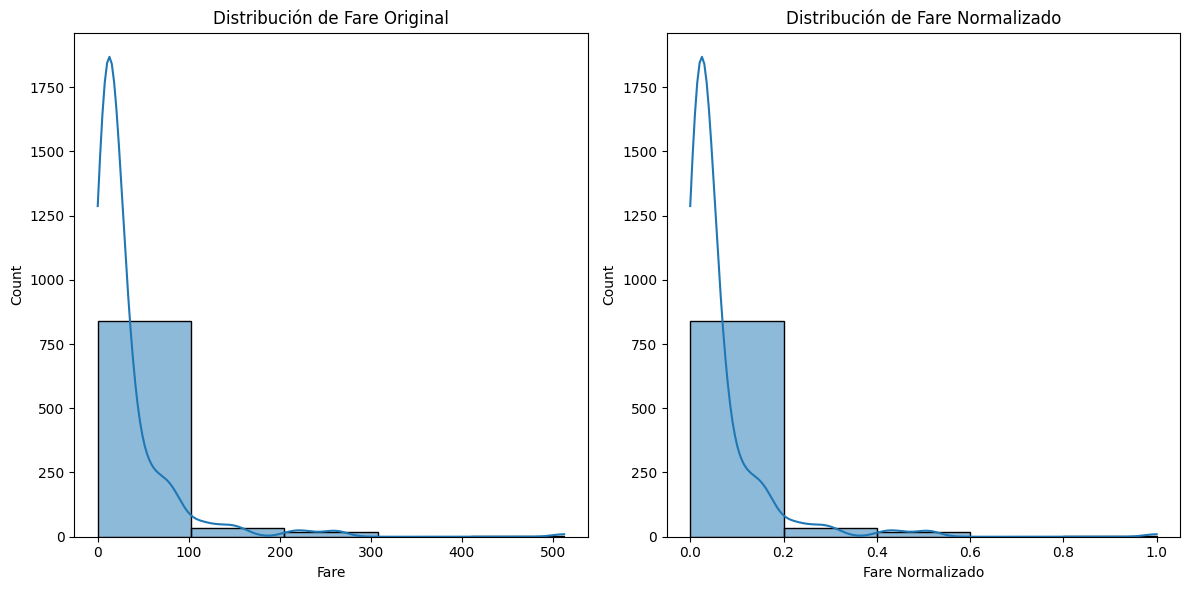

In [14]:
# Histograma compara 'Fare' y 'Fare Normalizado'
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

sns.histplot(df["fare"], bins=5, kde=True, ax=axes[0])
axes[0].set_title("Distribución de Fare Original")
axes[0].set_xlabel("Fare")

sns.histplot(df["fare_normalizado"], bins=5, kde=True, ax=axes[1])
axes[1].set_title("Distribución de Fare Normalizado")
axes[1].set_xlabel("Fare Normalizado")

plt.tight_layout()
plt.show()

# 3. Convierte la columna sex a valores numéricos usando One-Hot Encoding.


In [15]:
# One-Hot Encoding de la columna sex
df = pd.get_dummies(df, columns=["sex"], prefix="Sexo")

print("Datos transformados:\n", df[["fare", "fare_normalizado", "Sexo_female", "Sexo_male"]].head())

Datos transformados:
       fare  fare_normalizado  Sexo_female  Sexo_male
0   7.2500          0.014151        False       True
1  71.2833          0.139136         True      False
2   7.9250          0.015469         True      False
3  53.1000          0.103644         True      False
4   8.0500          0.015713        False       True


# 4. Explica qué impacto puede tener esta transformación en un modelo de clasificación.

La normalización Min-Max en fare escala valores entre 0 y 1, optimizando el entrenamiento en modelos basados en distancia y gradientes (KNN, SVM, redes neuronales) al evitar el predominio de números altos.

Por su parte, el One-Hot Encoding en sex convierte variables categóricas en formatos binarios, garantizando compatibilidad sin imponer un orden artificial falso. Si bien el One-Hot Encoding puede elevar la dimensionalidad, la baja cardinalidad de sex evita el sobreajuste.

Ambas técnicas adecuan los datos para maximizar el rendimiento del aprendizaje automático considerando una misma escala.

# **Preguntas de Reflexión**

*1. ¿Por qué One-Hot Encoding es mejor que Label Encoding en este caso?*

Label Encoding asigna valores numéricos arbitrarios (ej. 0 para 'female', 1 para 'male'), convirtiendo variables categóricas a numéricas. Esta asignación implica una relación de orden o jerarquía (0 < 1) que no existe entre los géneros.
Los algoritmos de ML podrían interpretar erróneamente esta relación ordinal artificial, sesgando el modelo.  Por ejemplo, un modelo podría considerar que 'male' (1) es 'mayor' o más importante que 'female' (0).

One-Hot Encoding, en cambio, crea nuevas columnas binarias para cada categoría única. Para 'sex', se generaran 'Sexo_female' y 'Sexo_male'. Cada fila tendría un 1 en la columna correspondiente a su género y 0 en las demás. Esto elimina cualquier suposición de orden o magnitud entre las categorías. Asegura que el modelo trate cada género como una entidad independiente y no relacionada jerárquicamente. Es ideal para variables categóricas nominales como 'sex', donde no hay un orden intrínseco, mejorando la precisión del modelo.


*2. ¿Cómo cambiaría el rendimiento de un modelo si usamos datos sin normalizar?*

Si no normalizamos, nos encontramos con diferencias de escala con rangos de valores muy diferentes pueden dominar el cálculo de distancias. Algoritmos como SVM, KNN y redes neuronales son muy sensibles a la escala de los datos. En modelos basados en gradientes, la optimización puede ser más lenta y menos estable.El algoritmo de aprendizaje puede tardar más en encontrar la solución óptima o incluso no converger.Algunos modelos podrían no funcionar correctamente o producir resultados erróneos.Las características con valores más grandes pueden tener un peso desproporcionado en la función de costo. Se vuelve difícil comparar la importancia relativa de diferentes características. El modelo puede tener una precisión de predicción general más baja. La interpretación de los coeficientes del modelo puede ser engañosa sin una escala uniforme.

*3. ¿Cuándo puede ser preferible usar una codificación ordinal?*

Es preferible usar una codificación ordinal:

* se analizan Variables Categóricas Ordinales, las categorías tienen un orden o jerarquía inherente (ej. 'pequeño', 'mediano', 'grande').
* mantiene la Relación Ordinal: La codificación asigna números que reflejan esta relación, como 0, 1, 2.
* reduce la Dimensionalidad, a diferencia de One-Hot Encoding, no crea nuevas columnas, manteniendo el número de características.
* algoritmos como árboles de decisión, bosques aleatorios o XGBoost pueden manejar bien la codificación ordinal.
* eficiencia computacional, al no expandir las características, puede ser más eficiente para datasets grandes.
* cuando la magnitud importa, si el modelo puede interpretar la magnitud numérica de forma significativa (ej. 'clase de pasajero' en Titanic).
* útil cuando el número de categorías es alto y One-Hot Encoding crearía muchas columnas dispersas.